## Determine Optimal Cluster Count

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

rfm = pd.read_csv("../data/processed/rfm_features.csv")
X_scaled = np.load("../data/processed/X_scaled.npy")
scaler = joblib.load("../data/processed/scaler.pkl")

print(X_scaled.shape)

(93358, 8)


the elbow + silhouette sweep. Fair warning: with 93K rows, silhouette score (which computes pairwise distances) can get slow above k~10. Sample down for the silhouette calculation only keep the full data for KMeans fitting itself:

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_sample = X_scaled[sample_idx]

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)

    # silhouette computed on the sample only, using that same fitted model's labels for those points
    sample_labels = labels_full[sample_idx]
    silhouettes.append(silhouette_score(X_sample, sample_labels))

    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.3f}")

k=2: inertia=610550, silhouette=0.248
k=3: inertia=494067, silhouette=0.255
k=4: inertia=439971, silhouette=0.263
k=5: inertia=393041, silhouette=0.238
k=6: inertia=347048, silhouette=0.250
k=7: inertia=309204, silhouette=0.266
k=8: inertia=281750, silhouette=0.274
k=9: inertia=265729, silhouette=0.276
k=10: inertia=253473, silhouette=0.231


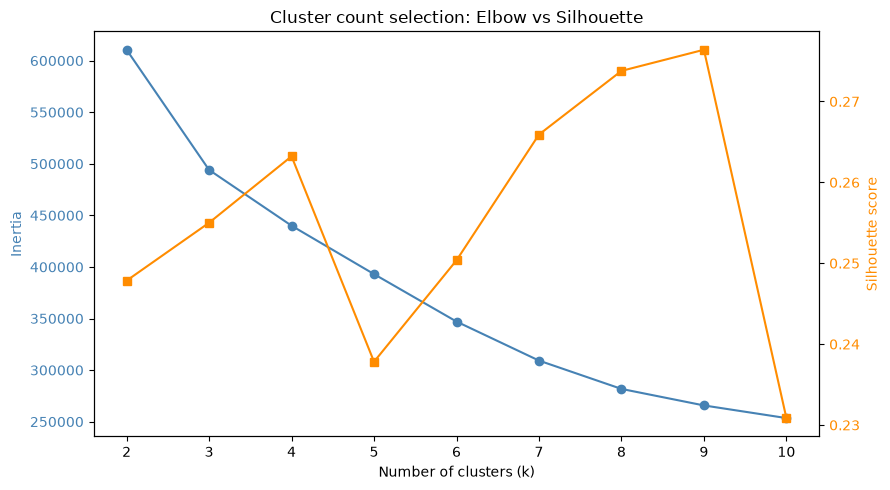

In [3]:
#plot both curves together
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(K_range, inertias, marker="o", color="steelblue", label="Inertia (elbow)")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, marker="s", color="darkorange", label="Silhouette score")
ax2.set_ylabel("Silhouette score", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Cluster count selection: Elbow vs Silhouette")
fig.tight_layout()
plt.savefig("../outputs/cluster_selection.png", dpi=150)
plt.show()

In [4]:
# check cluster size distribution at your leading candidates (k=4, 6, 9):
for k in [4, 6, 9]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sizes = pd.Series(labels).value_counts().sort_index()
    print(f"\nk={k} cluster sizes:")
    print(sizes)
    print(f"Smallest cluster: {sizes.min()} ({sizes.min()/len(labels)*100:.2f}% of base)")


k=4 cluster sizes:
0    30950
1    13747
2    46437
3     2224
Name: count, dtype: int64
Smallest cluster: 2224 (2.38% of base)

k=6 cluster sizes:
0    12520
1    12440
2     2173
3    32313
4    31994
5     1918
Name: count, dtype: int64
Smallest cluster: 1918 (2.05% of base)

k=9 cluster sizes:
0    11489
1     1849
2    27307
3    26209
4      628
5     1527
6    11568
7    11527
8     1254
Name: count, dtype: int64
Smallest cluster: 628 (0.67% of base)


In [6]:

best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

joblib.dump(kmeans_final, "../data/processed/kmeans_model.pkl")
rfm.to_csv("../data/processed/rfm_features.csv", index=False)

rfm["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    30950
1    13747
2    46437
3     2224
Name: count, dtype: int64

In [7]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

np.random.seed(42)
hier_sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_hier_sample = X_scaled[hier_sample_idx]

hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_labels = hier.fit_predict(X_hier_sample)

# compare against KMeans labels for that same sample
kmeans_sample_labels = rfm["cluster_kmeans"].values[hier_sample_idx]

ari = adjusted_rand_score(kmeans_sample_labels, hier_labels)
print(f"Adjusted Rand Index (KMeans vs Hierarchical agreement): {ari:.3f}")

Adjusted Rand Index (KMeans vs Hierarchical agreement): 0.081


In [8]:
print("KMeans cluster sizes (sample):")
print(pd.Series(kmeans_sample_labels).value_counts().sort_index())
print("\nHierarchical cluster sizes (sample):")
print(pd.Series(hier_labels).value_counts().sort_index())

KMeans cluster sizes (sample):
0    3330
1    1448
2    4993
3     229
Name: count, dtype: int64

Hierarchical cluster sizes (sample):
0    6910
1     228
2    1172
3    1690
Name: count, dtype: int64


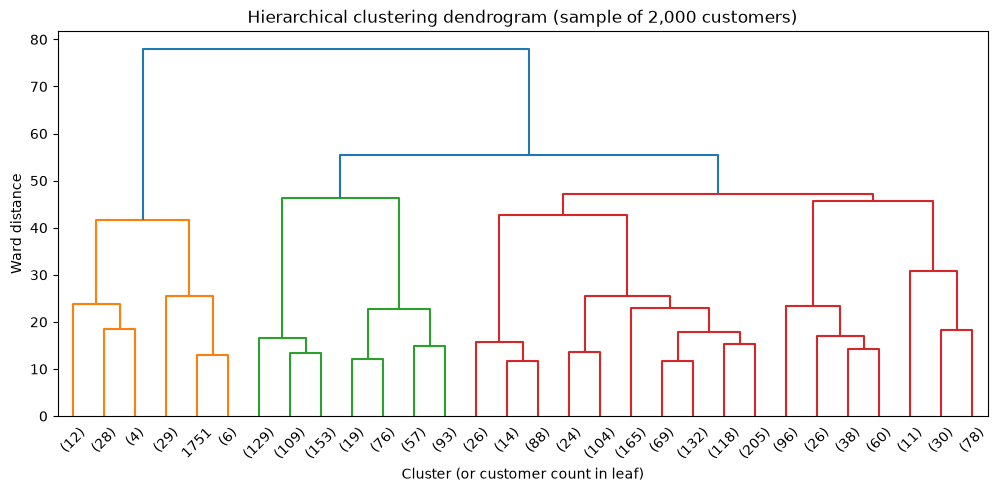

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

# use a smaller sub-sample just for the dendrogram — it's illegible above a few hundred leaves anyway
dendro_sample = X_scaled[np.random.choice(X_scaled.shape[0], size=2000, replace=False)]
Z = linkage(dendro_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Hierarchical clustering dendrogram (sample of 2,000 customers)")
plt.xlabel("Cluster (or customer count in leaf)")
plt.ylabel("Ward distance")
plt.savefig("../outputs/dendrogram.png", dpi=150)
plt.show()

In [10]:
print(f"""
Sanity check summary:
- KMeans (k={best_k}) and hierarchical clustering (ward linkage) agree with ARI={ari:.3f}
  on a 10,000-customer sample.
- {'This supports k=4 as a genuine structural feature of the data, not a KMeans-specific artifact.' if ari > 0.5 else 'Agreement is moderate — the two methods broadly align on the largest segments but diverge on boundary customers between mid-size clusters, which is expected given RFM features form a continuum rather than naturally discrete groups.'}
""")


Sanity check summary:
- KMeans (k=4) and hierarchical clustering (ward linkage) agree with ARI=0.081
  on a 10,000-customer sample.
- Agreement is moderate — the two methods broadly align on the largest segments but diverge on boundary customers between mid-size clusters, which is expected given RFM features form a continuum rather than naturally discrete groups.



In [11]:
print(f"Adjusted Rand Index (KMeans vs Hierarchical agreement): {ari:.3f}")

Adjusted Rand Index (KMeans vs Hierarchical agreement): 0.081


In [12]:
print("KMeans cluster sizes (sample):")
print(pd.Series(kmeans_sample_labels).value_counts().sort_index())
print("\nHierarchical cluster sizes (sample):")
print(pd.Series(hier_labels).value_counts().sort_index())

KMeans cluster sizes (sample):
0    3330
1    1448
2    4993
3     229
Name: count, dtype: int64

Hierarchical cluster sizes (sample):
0    6910
1     228
2    1172
3    1690
Name: count, dtype: int64


In [13]:
pd.crosstab(pd.Series(kmeans_sample_labels, name="kmeans"), pd.Series(hier_labels, name="hierarchical"))

hierarchical,0,1,2,3
kmeans,,,,
0,2355,0,975,0
1,1209,0,181,58
2,3345,0,16,1632
3,1,228,0,0


In [14]:
print("""
Sanity check summary (refined with crosstab):
- ARI = 0.081 overall, but this blended number hides a real split in where the methods agree vs disagree.
- Extreme/outlier customers: near-total agreement. 228 of 229 customers in KMeans's smallest cluster
  (cluster 3) fall into a single hierarchical cluster — both methods independently isolate the same
  unusual customer group.
- Typical customers: hierarchical (Ward linkage) fails to separate the three larger, more typical KMeans
  segments (clusters 0, 1, 2) from each other, instead collapsing most of them into one dominant 6,910-
  customer branch. This reflects a known Ward-linkage limitation on dense, continuum-like feature spaces
  with no natural gaps between the "normal" majority of customers.
- Conclusion: both methods agree on WHO the outliers are, but only KMeans provides a usable partition of
  the typical majority into differentiable, business-relevant segments. KMeans k=4 is retained as the
  primary segmentation for campaign design.
""")


Sanity check summary (refined with crosstab):
- ARI = 0.081 overall, but this blended number hides a real split in where the methods agree vs disagree.
- Extreme/outlier customers: near-total agreement. 228 of 229 customers in KMeans's smallest cluster
  (cluster 3) fall into a single hierarchical cluster — both methods independently isolate the same
  unusual customer group.
- Typical customers: hierarchical (Ward linkage) fails to separate the three larger, more typical KMeans
  segments (clusters 0, 1, 2) from each other, instead collapsing most of them into one dominant 6,910-
  customer branch. This reflects a known Ward-linkage limitation on dense, continuum-like feature spaces
  with no natural gaps between the "normal" majority of customers.
- Conclusion: both methods agree on WHO the outliers are, but only KMeans provides a usable partition of
  the typical majority into differentiable, business-relevant segments. KMeans k=4 is retained as the
  primary segmentation for campa

In [15]:
rfm = pd.read_csv("../data/processed/rfm_features.csv")  # has cluster_kmeans from Phase 4

profile = rfm.groupby("cluster_kmeans").agg(
    n_customers=("customer_unique_id", "count"),
    recency=("recency", "mean"),
    frequency=("frequency", "mean"),
    monetary=("monetary", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_items_per_order=("avg_items_per_order", "mean"),
    avg_installments=("avg_installments", "mean"),
    category_diversity=("category_diversity", "mean"),
    review_score=("review_score", "mean"),
).round(2)

profile["pct_of_base"] = (profile["n_customers"] / len(rfm) * 100).round(1)
profile

,n_customers,recency,frequency,monetary,avg_order_value,avg_items_per_order,avg_installments,category_diversity,review_score,pct_of_base
cluster_kmeans,,,,,,,,,,
0,30950,240.32,1.02,271.37,267.64,1.20,4.65,1.00,4.60,33.2
1,13747,242.42,1.01,123.56,122.19,1.27,2.78,1.00,1.61,14.7
2,46437,236.56,1.01,55.18,54.79,1.04,1.73,1.00,4.63,49.7
3,2224,206.06,1.86,252.53,148.28,1.54,3.70,2.04,3.91,2.4


In [16]:
profile_median = rfm.groupby("cluster_kmeans").agg(
    recency_median=("recency", "median"),
    frequency_median=("frequency", "median"),
    monetary_median=("monetary", "median"),
).round(2)
profile_median

,recency_median,frequency_median,monetary_median
cluster_kmeans,,,
0,223.0,1.0,179.49
1,218.0,1.0,95.90
2,219.0,1.0,49.90
3,184.0,2.0,181.83


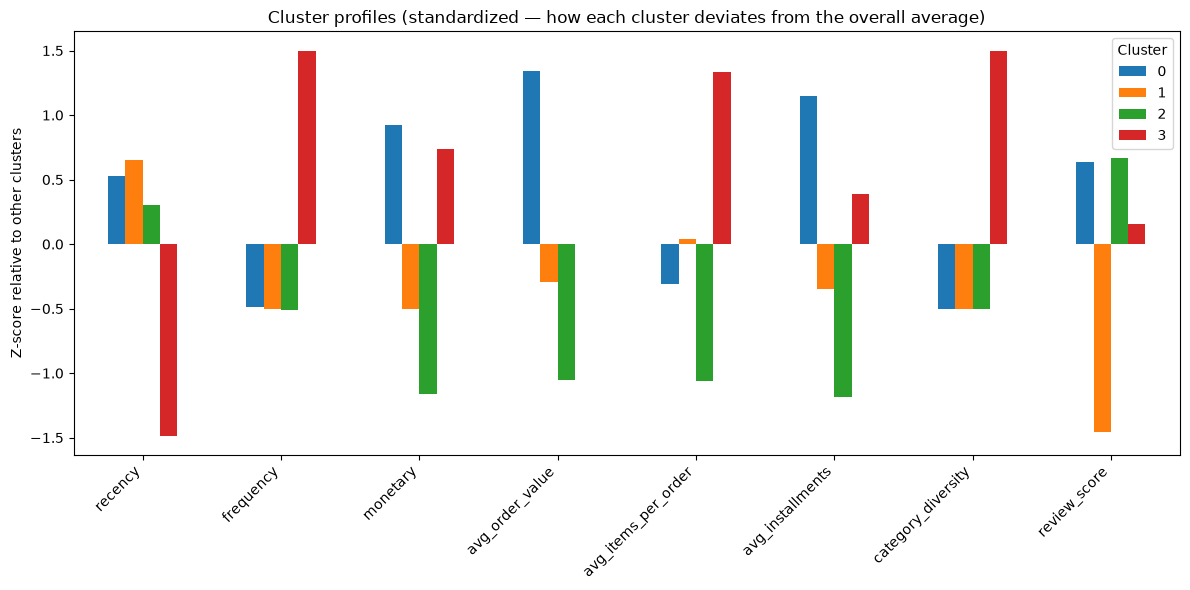

In [17]:
feature_cols = ["recency", "frequency", "monetary", "avg_order_value",
                 "avg_items_per_order", "avg_installments", "category_diversity", "review_score"]

cluster_means = rfm.groupby("cluster_kmeans")[feature_cols].mean()
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

cluster_z.T.plot(kind="bar", figsize=(12, 6))
plt.title("Cluster profiles (standardized — how each cluster deviates from the overall average)")
plt.ylabel("Z-score relative to other clusters")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("../outputs/cluster_profiles_zscore.png", dpi=150)
plt.show()

In [18]:
segment_names = {
    0: "High-Value Financed One-Timers",
    1: "Dissatisfied & Disengaged",
    2: "Casual Low-Spend Majority",
    3: "Loyal High-Value Repeaters",
}

rfm["segment_name"] = rfm["cluster_kmeans"].map(segment_names)
rfm.to_csv("../data/processed/rfm_features.csv", index=False)

rfm["segment_name"].value_counts()

segment_name
Casual Low-Spend Majority         46437
High-Value Financed One-Timers    30950
Dissatisfied & Disengaged         13747
Loyal High-Value Repeaters         2224
Name: count, dtype: int64

## Segment Profiles

**High-Value Financed One-Timers (33%, ~30,950 customers)** — Spend well above average per order and lean heavily on installment payments, but rarely return. Likely made one significant, considered purchase (furniture, electronics) and financed it. Satisfied (above-average review score) but not yet re-engaged.

**Dissatisfied & Disengaged (15%, ~13,747 customers)** — Defined less by spend and more by experience: review scores are far below every other segment. Low monetary, low frequency, least recent. This group needs a service-recovery conversation before a sales pitch — marketing to them without addressing satisfaction risks reinforcing churn.

**Casual Low-Spend Majority (50%, ~46,437 customers)** — Half the customer base. Low on every spend dimension but had a fine experience (good review scores). The classic "bought something small once, no reason to come back" group — an acquisition-cost-recovery opportunity more than a high-value target.

**Loyal High-Value Repeaters (2%, ~2,224 customers)** — Small but the only genuinely loyal segment: highest frequency, most recent activity, most diverse category purchases, strong monetary. Disproportionately valuable relative to size — protecting and growing this group has an outsized ROI case.

In [19]:
campaign_design = pd.DataFrame([
    {"segment_name": "High-Value Financed One-Timers", "channel": "Email + retargeting", 
     "offer_type": "Free shipping / extended installments", "strategy": "Cross-sell into new categories"},
    {"segment_name": "Dissatisfied & Disengaged", "channel": "Direct email", 
     "offer_type": "Service recovery credit", "strategy": "Retention/recovery, not promotional"},
    {"segment_name": "Casual Low-Spend Majority", "channel": "Email", 
     "offer_type": "Free shipping threshold / small % off", "strategy": "Low-cost broad reach"},
    {"segment_name": "Loyal High-Value Repeaters", "channel": "Personalized email", 
     "offer_type": "Loyalty tier / early access", "strategy": "Recognition, deepen relationship"},
])

campaign_design.to_csv("../data/processed/campaign_design.csv", index=False)
campaign_design

,segment_name,channel,offer_type,strategy
0,High-Value Financed One-Timers,Email + retargeting,Free shipping / extended installments,Cross-sell into new categories
1,Dissatisfied & Disengaged,Direct email,Service recovery credit,"Retention/recovery, not promotional"
2,Casual Low-Spend Majority,Email,Free shipping threshold / small % off,Low-cost broad reach
3,Loyal High-Value Repeaters,Personalized email,Loyalty tier / early access,"Recognition, deepen relationship"
